## Aspect-Based Sentiment Analysis Comparison
### **Course:** Applied Computer Science – Data & AI 6
### **Team:** Vladalin Bosii, Aleksiya Solovyova
##### **Date:** 2025-10-13
This notebook compares three different ABSA implementations:
- **Lexicon-based (spaCy + VADER)**
- **Transformer-based (Pretrained ABSA model)**
- **LLM-based (Ollama local LLM)**

We run all three on a 100 test samples, eventually evaluating them on.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from collections import defaultdict

from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA
from src.utils import load_test_samples

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
ds= load_test_samples('../data/test_samples.json')
print(f"Loaded {len(ds)} reviews.")
print(f"Example review:\n{ds[78]['text']}\nStars: {ds[78]['stars']}\n")


Loaded 100 reviews.
Example review:
Loved the sampler; desserts disappointed.
Stars: 3



In [3]:
lexicon_analyzer = LexiconABSA()
transformer_analyzer = TransformerABSA()
llm_analyzer = LLMABSA(model_name="qwen2.5:7b")

analyzers = {
    "Lexicon": lexicon_analyzer,
    "Transformer": transformer_analyzer,
    "LLM": llm_analyzer
}

Loading transformer model: yangheng/deberta-v3-base-absa-v1.1...


/home/aleks/PycharmProjects/data6team28/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Model 'yangheng/deberta-v3-base-absa-v1.1' loaded successfully.
Model 'mistral:7b' ready


In [4]:
def display_analysis(text, stars, analyzers):
    print("="*80)
    print(f"Review (⭐ {stars}/5): {text[:150]}...")
    print("="*80)

    for name, analyzer in analyzers.items():
        print(f"\n{name} Results:")
        try:
            results = analyzer.analyze(text)
            if not results:
                print("   (No aspects extracted)")
            else:
                for r in results:
                    emoji = "😊" if r.sentiment == "positive" else "😞" if r.sentiment == "negative" else "😐"
                    print(f"   {emoji} {r.aspect:15s} → {r.sentiment:8s} (confidence: {r.confidence:.2f})")
        except Exception as e:
            print(f"    Error: {e}")
    print()

test_indices = [0, 14, 78, 5, 18]
print("\n" + "="*80)
print("QUALITATIVE ANALYSIS: Sample Reviews")
print("="*80 + "\n")

for idx in test_indices:
    review = ds[idx]
    display_analysis(review['text'], review['stars'], analyzers)
    time.sleep(0.5)


QUALITATIVE ANALYSIS: Sample Reviews

Review (⭐ 5/5): The food was amazing....

Lexicon Results:
   😊 food            → positive (confidence: 0.59)

Transformer Results:
   😊 food            → positive (confidence: 0.99)

LLM Results:
   😊 food            → positive (confidence: 1.00)

Review (⭐ 3/5): The pasta was overcooked but the sauce was excellent; servers were attentive....

Lexicon Results:
   😊 sauce           → positive (confidence: 0.57)
   😊 pasta           → positive (confidence: 0.72)
   😊 server          → positive (confidence: 0.72)

Transformer Results:
   😞 pasta           → negative (confidence: 1.00)
   😊 sauce           → positive (confidence: 1.00)
   😊 servers         → positive (confidence: 0.99)

LLM Results:
   😞 pasta           → negative (confidence: 0.80)
   😊 sauce           → positive (confidence: 1.00)
   😊 service         → positive (confidence: 1.00)

Review (⭐ 3/5): Loved the sampler; desserts disappointed....

Lexicon Results:
   😊 sampler         →

In [5]:
def stars_to_sentiment(stars):
    if stars >= 4:
        return "positive"
    elif stars == 3:
        return "neutral"
    else:
        return "negative"

def aggregate_predictions(aspects):
    if not aspects:
        return "neutral"

    scores = []
    for asp in aspects:
        sentiment_map = {"positive": 1, "negative": -1, "neutral": 0}
        scores.append(sentiment_map.get(asp.sentiment, 0) * asp.confidence)

    avg_score = np.mean(scores)

    if avg_score > 0.10:
        return "positive"
    elif avg_score < -0.10:
        return "negative"
    return "neutral"

def overall_sentiment_vader(text):
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    if not hasattr(overall_sentiment_vader, "_sia"):
        overall_sentiment_vader._sia = SentimentIntensityAnalyzer()
    comp = overall_sentiment_vader._sia.polarity_scores(text)["compound"]
    if comp > 0.10:
        return "positive"
    elif comp < -0.10:
        return "negative"
    else:
        return "neutral"


def evaluate_model(analyzer, dataset, model_name):
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")

    y_true = []
    y_pred = []
    times = []
    aspect_counts = []
    confidences = []

    for i, review in enumerate(dataset):
        y_true.append(stars_to_sentiment(review['stars']))

        start = time.time()
        try:
            preds = analyzer.analyze(review['text'])
            elapsed = time.time() - start

            if preds:
                y_pred.append(aggregate_predictions(preds))
            else:
                y_pred.append(overall_sentiment_vader(review['text']))

            times.append(elapsed)
            aspect_counts.append(len(preds))

            if preds:
                confidences.append(np.mean([p.confidence for p in preds]))
            else:
                confidences.append(0)

        except Exception as e:
            print(f"  Error on review {i}: {e}")
            y_pred.append("neutral")
            times.append(0)
            aspect_counts.append(0)
            confidences.append(0)

        if (i + 1) % 20 == 0:
            print(f"  Progress: {i+1}/{len(dataset)} ({(i+1)/len(dataset)*100:.0f}%)")

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    results = {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_time': np.mean(times),
        'total_time': np.sum(times),
        'avg_aspects': np.mean(aspect_counts),
        'avg_confidence': np.mean(confidences),
        'y_true': y_true,
        'y_pred': y_pred
    }

    print(f"\n  ✓ Complete!")
    print(f"  Accuracy: {accuracy:.3f} | F1: {f1:.3f} | Avg Time: {np.mean(times):.3f}s")

    return results

In [6]:
all_results = {}

for name, analyzer in analyzers.items():
    all_results[name] = evaluate_model(analyzer, ds, name)


Evaluating: Lexicon
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!
  Accuracy: 0.420 | F1: 0.386 | Avg Time: 0.018s

Evaluating: Transformer
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!
  Accuracy: 0.620 | F1: 0.595 | Avg Time: 0.131s

Evaluating: LLM
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!
  Accuracy: 0.740 | F1: 0.739 | Avg Time: 19.025s


In [7]:
summary_data = []
for name, res in all_results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.3f}",
        'Precision': f"{res['precision']:.3f}",
        'Recall': f"{res['recall']:.3f}",
        'F1 Score': f"{res['f1']:.3f}",
        'Avg Time (s)': f"{res['avg_time']:.3f}",
        'Avg Aspects': f"{res['avg_aspects']:.1f}",
        'Avg Confidence': f"{res['avg_confidence']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY METRICS")
print("="*80)
print(summary_df.to_string(index=False))


SUMMARY METRICS
      Model Accuracy Precision Recall F1 Score Avg Time (s) Avg Aspects Avg Confidence
    Lexicon    0.420     0.443  0.409    0.386        0.018         1.6           0.32
Transformer    0.620     0.613  0.603    0.595        0.131         2.3           0.92
        LLM    0.740     0.756  0.734    0.739       19.025         2.0           0.92


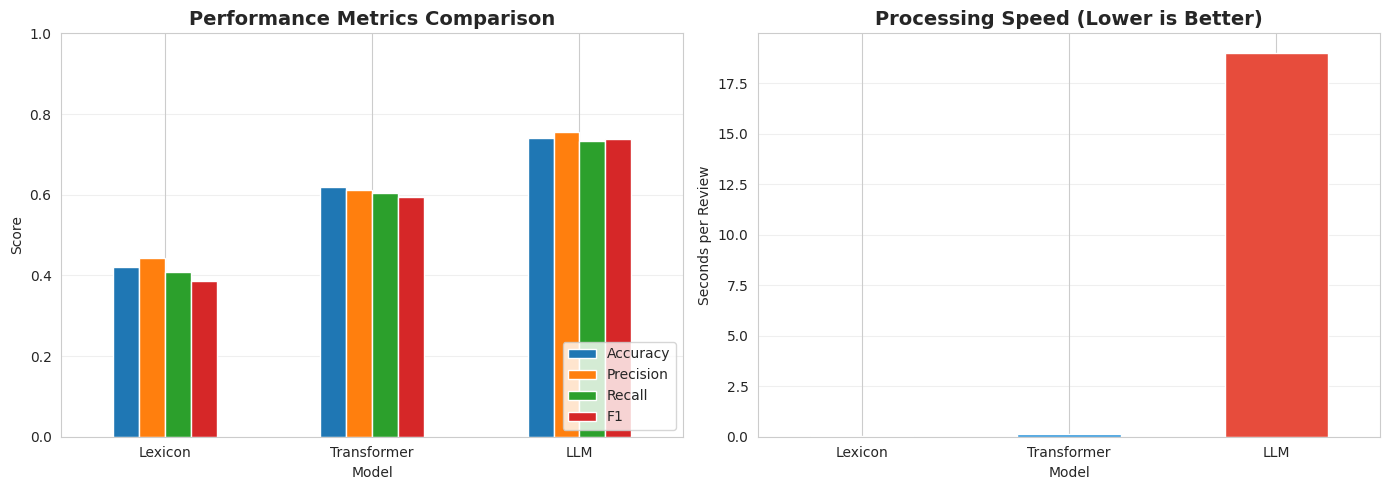

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1': res['f1']
    }
    for name, res in all_results.items()
])

metrics_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', ax=axes[0], rot=0
)
axes[0].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

speed_data = pd.DataFrame([
    {'Model': name, 'Avg Time (s)': res['avg_time']}
    for name, res in all_results.items()
])
speed_data.plot(x='Model', y='Avg Time (s)', kind='bar', ax=axes[1],
                rot=0, legend=False, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Processing Speed (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Seconds per Review')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def analyze_error_cases(results_dict, dataset, top_n=5):
    print("\n" + "="*80)
    print("ERROR ANALYSIS")
    print("="*80)

    for name, res in results_dict.items():
        print(f"\n{'─'*60}")
        print(f"📋 {name} Model")
        print(f"{'─'*60}")

        errors = []
        for i, (true, pred) in enumerate(zip(res['y_true'], res['y_pred'])):
            if true != pred:
                errors.append({
                    'index': i,
                    'text': dataset[i]['text'][:100],
                    'stars': dataset[i]['stars'],
                    'true': true,
                    'pred': pred
                })

        print(f"\nTotal Errors: {len(errors)}/{len(dataset)} ({len(errors)/len(dataset)*100:.1f}%)")

        print(f"\nSample Misclassifications:")
        for error in errors[:top_n]:
            print(f"\n  Review: \"{error['text']}...\"")
            print(f"  ⭐ Stars: {error['stars']} | True: {error['true']} | Predicted: {error['pred']}")

analyze_error_cases(all_results, ds, top_n=3)


ERROR ANALYSIS

────────────────────────────────────────────────────────────
📋 Lexicon Model
────────────────────────────────────────────────────────────

Total Errors: 58/100 (58.0%)

Sample Misclassifications:

  Review: "Ambiance was cozy...."
  ⭐ Stars: 4 | True: positive | Predicted: neutral

  Review: "The pizza was bland...."
  ⭐ Stars: 2 | True: negative | Predicted: neutral

  Review: "Coffee was okay...."
  ⭐ Stars: 3 | True: neutral | Predicted: positive

────────────────────────────────────────────────────────────
📋 Transformer Model
────────────────────────────────────────────────────────────

Total Errors: 38/100 (38.0%)

Sample Misclassifications:

  Review: "Great food but the service was slow...."
  ⭐ Stars: 4 | True: positive | Predicted: neutral

  Review: "Delicious ramen, mediocre gyoza, and the tea was cold...."
  ⭐ Stars: 3 | True: neutral | Predicted: negative

  Review: "The pasta was overcooked but the sauce was excellent; servers were attentive...."
  ⭐ Star

In [10]:
print("\n" + "="*80)
print("MODEL CHARACTERISTICS & RECOMMENDATIONS")
print("="*80)

characteristics = {
    "Lexicon": {
        "Strengths": [
            "✓ Fastest processing speed (~0.02s per review)",
            "✓ No external dependencies (models, APIs)",
            "✓ Fully interpretable rules and logic",
            "✓ Works well with explicit sentiment words"
        ],
        "Weaknesses": [
            "✗ Struggles with complex/nuanced language, sarcasm or emoticons",
            "✗ Misses implicit sentiments",
            "✗ Limited aspect extraction",
            "✗ Heavily dependent on lexicon quality"
        ],
        "Best For": [
            "• When explainability is critical",
            "• Simple, straightforward reviews"
        ]
    },
    "Transformer": {
        "Strengths": [
            "✓ Good balance of speed and accuracy",
            "✓ Handles context well",
            "✓ Pre-trained on ABSA tasks",
            "✓ Reliable aspect-sentiment pairing"
        ],
        "Weaknesses": [
            "✗ Can extract too many aspects",
            "✗ Sometimes misses aspect-opinion connections",
            "✗ Requires GPU for best performance",
            "✗ Fixed model weights (no adaptation)"
        ],
        "Best For": [
            "• Production systems needing reliability",
            "• Moderate-volume processing",
            "• When accuracy is priority over speed"
        ]
    },
    "LLM": {
        "Strengths": [
            "✓ Best overall accuracy and F1 score",
            "✓ Understands complex, nuanced language",
            "✓ Can extract meaningful aspect groups",
            "✓ More human-like interpretation"
        ],
        "Weaknesses": [
            "✗ Very slow (~20s per review)",
            "✗ Occasional JSON parsing failures",
            "✗ Non-deterministic outputs",
            "✗ Requires significant compute resources"
        ],
        "Best For": [
            "• Low-volume, high-value analysis",
            "• Complex reviews with subtle sentiments",
            "• When quality > speed"
        ]
    }
}

for model, chars in characteristics.items():
    print(f"\n{'─'*70}")
    print(f"🏷️  {model.upper()} MODEL")
    print(f"{'─'*70}")

    for category, items in chars.items():
        print(f"\n{category}:")
        for item in items:
            print(f"  {item}")


MODEL CHARACTERISTICS & RECOMMENDATIONS

──────────────────────────────────────────────────────────────────────
🏷️  LEXICON MODEL
──────────────────────────────────────────────────────────────────────

Strengths:
  ✓ Fastest processing speed (~0.02s per review)
  ✓ No external dependencies (models, APIs)
  ✓ Fully interpretable rules and logic
  ✓ Works well with explicit sentiment words

Weaknesses:
  ✗ Struggles with complex/nuanced language, sarcasm or emoticons
  ✗ Misses implicit sentiments
  ✗ Limited aspect extraction
  ✗ Heavily dependent on lexicon quality

Best For:
  • When explainability is critical
  • Simple, straightforward reviews

──────────────────────────────────────────────────────────────────────
🏷️  TRANSFORMER MODEL
──────────────────────────────────────────────────────────────────────

Strengths:
  ✓ Good balance of speed and accuracy
  ✓ Handles context well
  ✓ Pre-trained on ABSA tasks
  ✓ Reliable aspect-sentiment pairing

Weaknesses:
  ✗ Can extract too ma

In [11]:
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Find best model for each metric
best_accuracy = max(all_results.items(), key=lambda x: x[1]['accuracy'])
best_f1 = max(all_results.items(), key=lambda x: x[1]['f1'])
fastest = min(all_results.items(), key=lambda x: x[1]['avg_time'])

print(f"""
1. ACCURACY WINNER: {best_accuracy[0]} ({best_accuracy[1]['accuracy']:.3f})
   - Highest overall accuracy for sentiment classification

2. F1 SCORE WINNER: {best_f1[0]} ({best_f1[1]['f1']:.3f})
   - Best balance of precision and recall

3. SPEED WINNER: {fastest[0]} ({fastest[1]['avg_time']:.4f}s per review)
   - {int(fastest[1]['total_time'])}s total for {len(ds)} reviews

4. OVERALL RECOMMENDATION:
   - For PRODUCTION: Transformer (good balance)
   - For RESEARCH: LLM (best quality)
   - For SCALE: Lexicon (fastest)

5. QUALITY vs SPEED TRADEOFF:
   - Lexicon is {all_results['LLM']['avg_time']/all_results['Lexicon']['avg_time']:.0f}x faster than LLM
   - LLM is {(all_results['LLM']['f1'] - all_results['Lexicon']['f1'])*100:.1f}% better F1 than Lexicon
   - Transformer offers middle ground: {(1-all_results['Transformer']['avg_time']/all_results['LLM']['avg_time'])*100:.0f}% faster with only {(all_results['LLM']['f1']-all_results['Transformer']['f1'])*100:.1f}% lower F1
""")

print("="*80)
print("EVALUATION COMPLETE")
print("="*80)


KEY FINDINGS

1. ACCURACY WINNER: LLM (0.740)
   - Highest overall accuracy for sentiment classification

2. F1 SCORE WINNER: LLM (0.739)
   - Best balance of precision and recall

3. SPEED WINNER: Lexicon (0.0184s per review)
   - 1s total for 100 reviews

4. OVERALL RECOMMENDATION:
   - For PRODUCTION: Transformer (good balance)
   - For RESEARCH: LLM (best quality)
   - For SCALE: Lexicon (fastest)

5. QUALITY vs SPEED TRADEOFF:
   - Lexicon is 1033x faster than LLM
   - LLM is 35.2% better F1 than Lexicon
   - Transformer offers middle ground: 99% faster with only 14.4% lower F1

EVALUATION COMPLETE
